/Users/shivin/miniconda/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


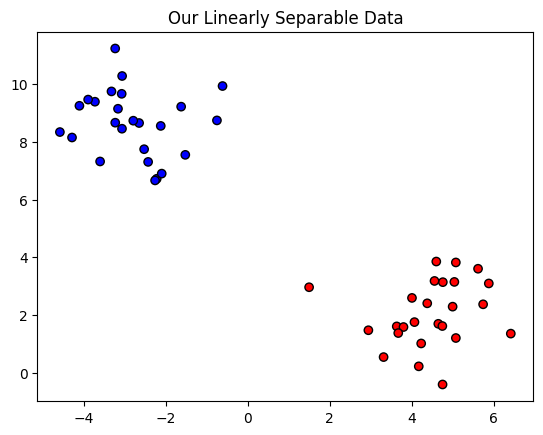

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Let's generate a simple, separable dataset
X, y = make_blobs(n_samples=50, centers=2, random_state=42, cluster_std=1.2)

# IMPORTANT: SVMs expect labels to be -1 and 1, not 0 and 1!
y = np.where(y == 0, -1, 1)

# Let's look at our data
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.title("Our Linearly Separable Data")
plt.show()

In [4]:
class SVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param # Regularization parameter (helps maximize margin)
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # 1. Initialize weights and bias to zeros
        self.w = np.zeros(n_features)
        self.b = 0

        # 2. Gradient Descent Loop
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                
                # Check if the point is correctly classified and outside the margin
                # TODO                
                if condition:
                    # Point is safe! Only apply regularization to maximize margin
                    dw = #TODO
                    db = 0
                else:
                    # Point is on the wrong side! Calculate loss gradients
                    dw = # TODO
                    db = -y[idx]

                # 3. Update the weights and bias taking a small step
                self.w -= self.lr * dw
                self.b -= self.lr * db

    def predict(self, X):
        # Equation of the line: w.x + b
        linear_output = # TODO
        # Return +1 if positive, -1 if negative
        return np.sign(linear_output)

Learned Weights: [ 0.62325698 -0.10498961]
Learned Bias: 0.3790000000000003


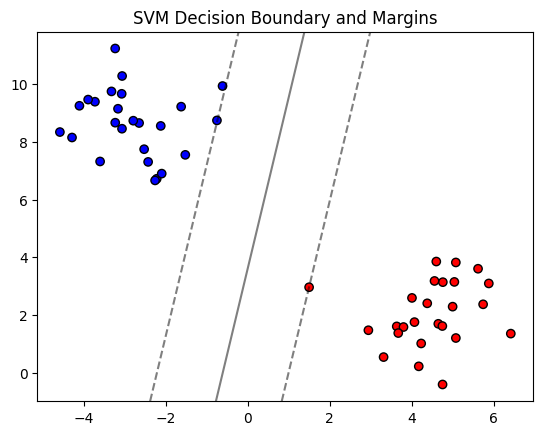

In [5]:
# 1. Initialize and train our model
clf = SVM(learning_rate=0.001, lambda_param=0.01, n_iters=1000)
clf.fit(X, y)

print(f"Learned Weights: {clf.w}")
print(f"Learned Bias: {clf.b}")

# 2. Helper function to plot the decision boundary
def visualize_svm(X, y, model):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
    
    # Create a grid to evaluate model
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    
    # Get predictions for the grid
    Z = (np.dot(xy, model.w) + model.b).reshape(XX.shape)
    
    # Plot decision boundary and margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    plt.title("SVM Decision Boundary and Margins")
    plt.show()

# 3. Plot!
visualize_svm(X, y, clf)

### Ex: Compare SVM with LR and Naive Bayes on the same dataset